In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [49]:
import matplotlib.cm as cm

In [50]:

import scienceplots

In [51]:
# min: 30mm
# single col: 90mm
# 1.5 col: 140mm
# double col: 190mm
# convert to inches: divide by 25.4
min_width = 30 / 25.4
single_col_width = 90 / 25.4
one_half_col_width = 140 / 25.4
double_col_width = 190 / 25.4

In [52]:
plt.style.use([
    'science', 
    # 'ieee'
    ])
plt.rcParams['figure.figsize'] = [single_col_width, 2.36]
dpi = 300
plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi'] = dpi

In [53]:
import ternary

In [54]:
# !pip3 install python-ternary

In [55]:
DetectorReadings = pd.read_csv('DetectorReadings.csv', index_col=0)
sims = pd.read_csv('sims.csv', index_col=0)
sims.set_index('label', inplace=True)
soilinfos = pd.read_json('soilinfos.json')

In [56]:
sims['avg_density'] = soilinfos.density_mat.apply(lambda x: np.average(x))

In [57]:
elem_sims = sims[~sims['elem'].isna()]
elem_Readings = DetectorReadings[elem_sims.index]

In [58]:
_sims = elem_sims
_Readings = elem_Readings

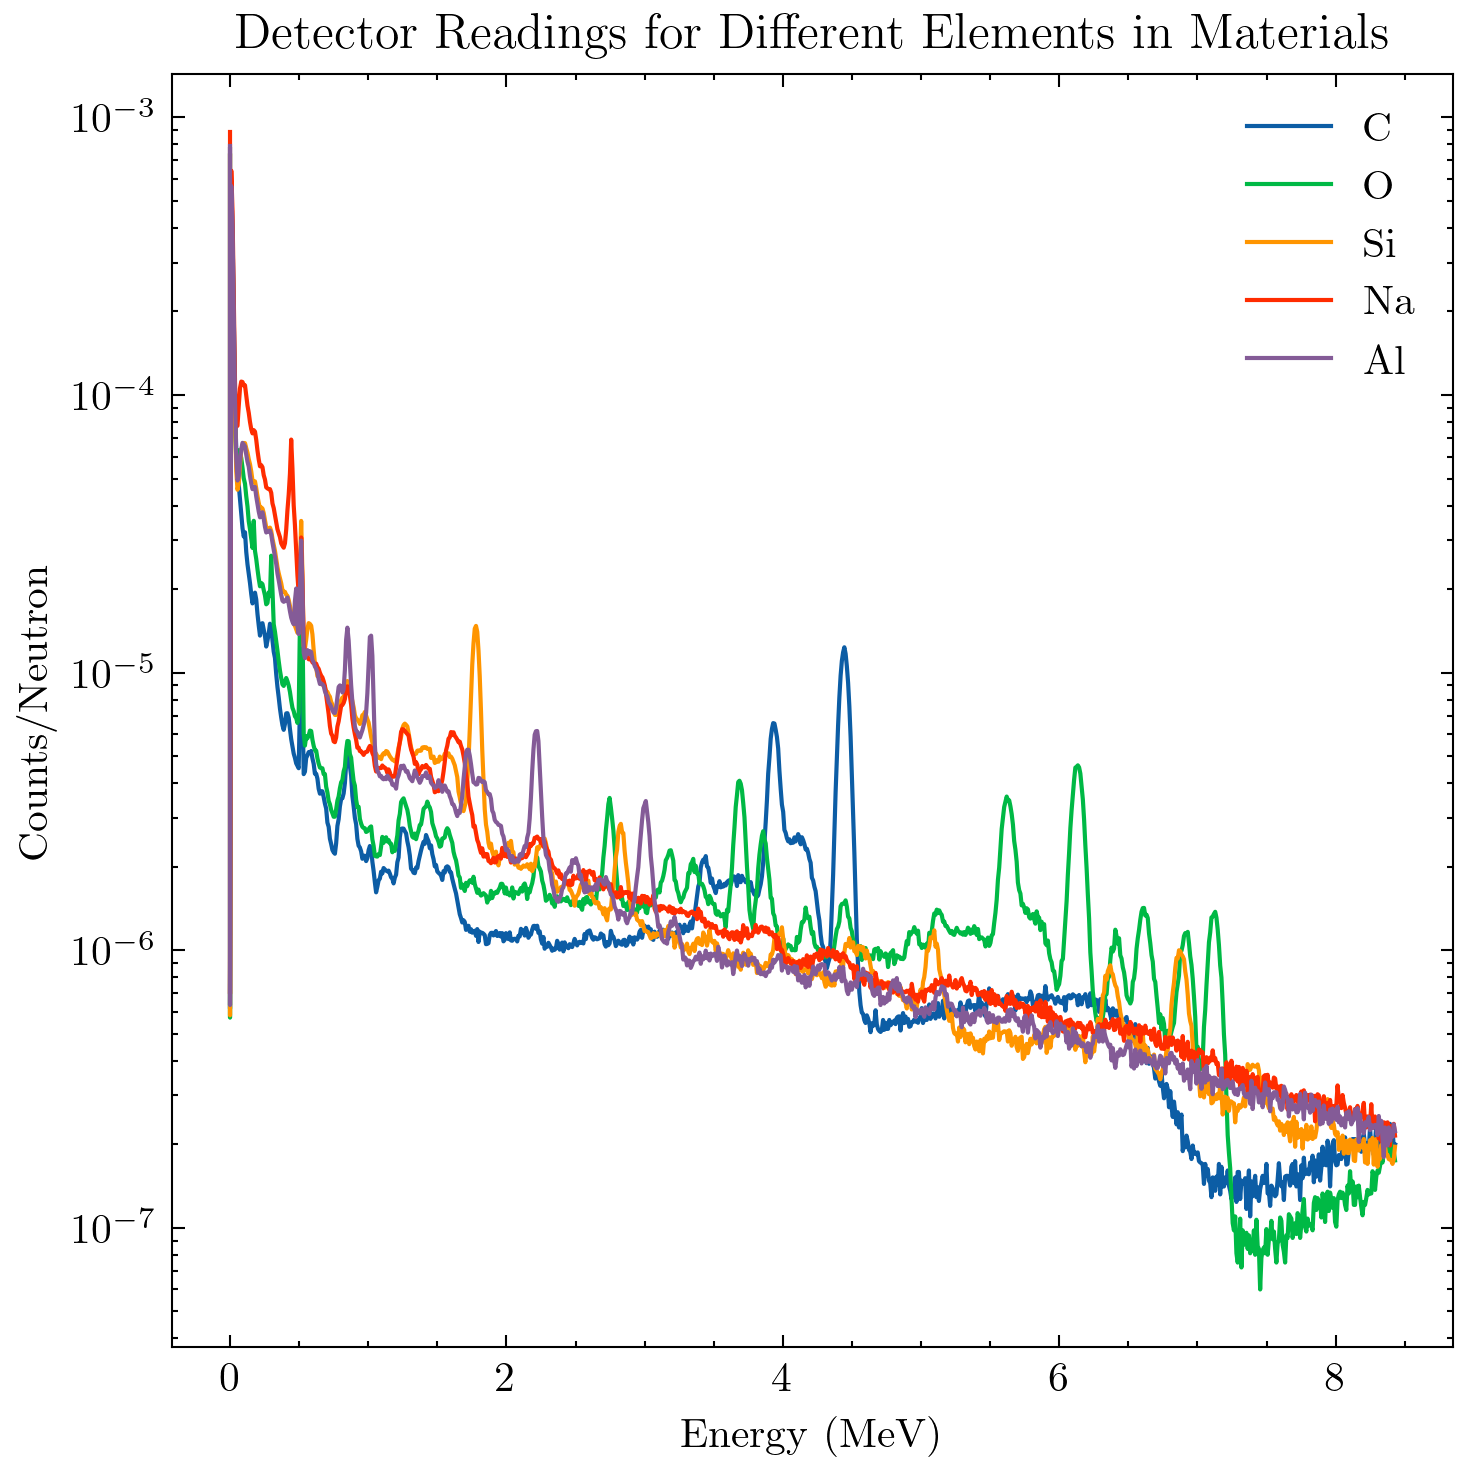

In [59]:
_sims = elem_sims
_sims = _sims.loc[['C', 'O', 'Si', 'Na', 'Al']]
_Readings = elem_Readings

plt.figure(figsize=(one_half_col_width  , one_half_col_width))
for label, row in _sims.iterrows():
    plt.plot(_Readings.index, _Readings[label], label=f"{row['elem']}")
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts/Neutron')
plt.title('Detector Readings for Different Elements in Materials')
plt.legend()
# plt.savefig('../Figures/Simulation/ElemDetectorReadings.png', dpi=100, bbox_inches='tight')
plt.show()

In [60]:
_colors = {
    'C': '#882255', 
    'O':'#66CCEE', 
    'Si': '#CCBB44'}

_linestyles = {
    'C': 'solid', 
    'O':'dashed', 
    'Si': 'dotted'}

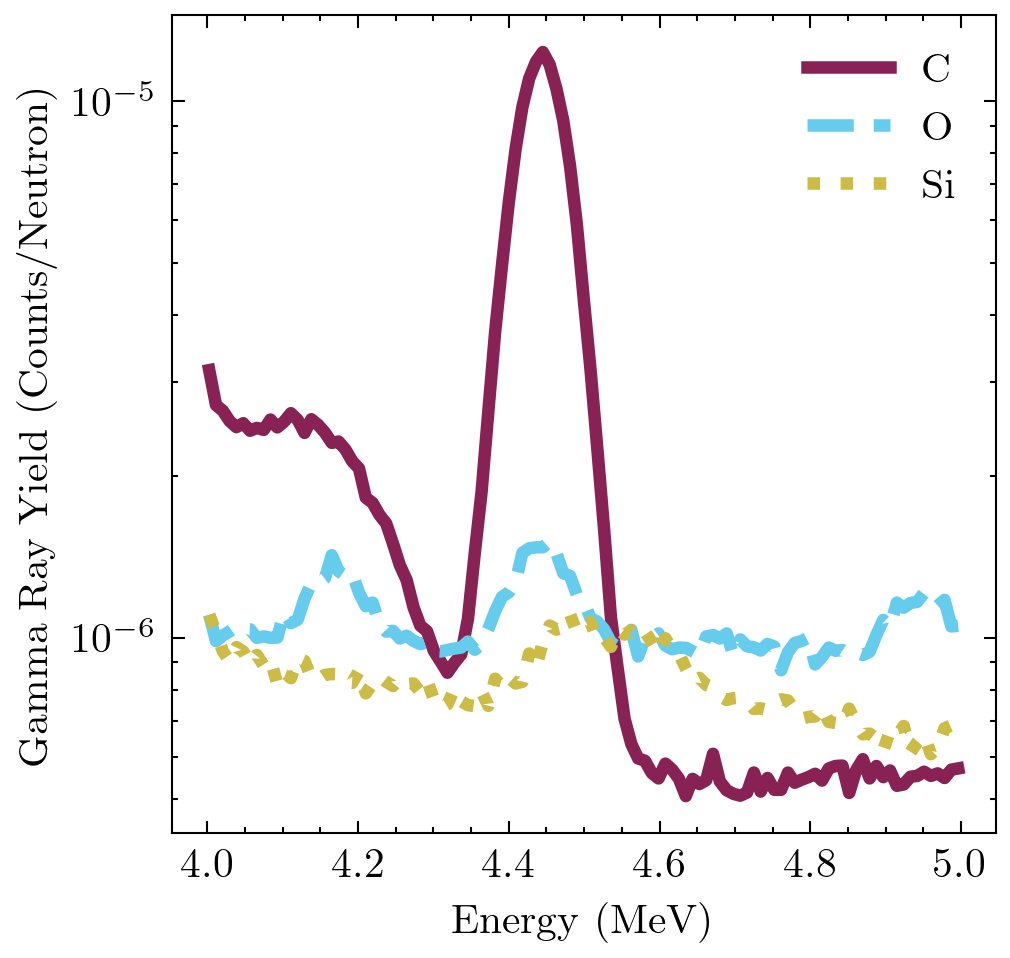

In [97]:
_sims = elem_sims
_sims = _sims.loc[['C', 'O', 'Si']]
_Readings = elem_Readings
_Readings = _Readings.loc[(_Readings.index < 5) & (_Readings.index > 4)]

plt.figure(figsize=(single_col_width, single_col_width))
for label, row in _sims.iterrows():
    plt.plot(_Readings.index, _Readings[label], label=f"{row['elem']}", color=_colors[row['elem']], linestyle=_linestyles[row['elem']], linewidth=3)
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Gamma Ray Yield (Counts/Neutron)')
# plt.title('Multiple Peaks at 4.44 MeV')
# plt.axvline(x=4.44, color='k', linestyle='--', label='C Gamma')
plt.legend()
plt.savefig('../Figures/Simulation/ElemDetectorReadingsCGamma.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
_Readings = _Readings.loc[(_Readings.index < 4) & (_Readings.index > 0.1)]

In [63]:
material_sims = sims[sims['material'].notna() | (sims['elem'] == 'C')]


In [64]:
material_sims = material_sims.query('(hydration_level == 0 and carbon_level == 0) or elem == "C" or material == "Water"')

In [65]:
material_sims = material_sims[(material_sims['avg_density'] < 1.4) & (material_sims['avg_density'] > 1.3)]

In [66]:
material_Readings = DetectorReadings[material_sims.index]

In [67]:
_det_mat = DetectorReadings.to_numpy()
np.average(np.average(np.divide(np.abs(np.subtract(_det_mat, np.average(_det_mat, axis=1)[:, None])), np.average(_det_mat, axis=1)[:, None]), axis=1))

np.float64(0.0878688865782062)

In [68]:
# without C or water
mat_det_mat = material_Readings[material_sims[~material_sims.index.isin(['C', 'Water'])].index].to_numpy()

In [69]:
_det_mat = mat_det_mat
np.average(np.average(np.divide(np.abs(np.subtract(_det_mat, np.average(_det_mat, axis=1)[:, None])), np.average(_det_mat, axis=1)[:, None]), axis=1))

np.float64(0.04922575221433621)

In [70]:
changed_styles = {
    'C':{
        'color': '#882255',
        'linestyle': 'solid'
    },
    'Water':{
        'color': '#332288',
        'linestyle': 'solid'
    },
    'Mica':{
        'color': "#0B0B0B",
        'linestyle': 'dotted',
        'marker': 'o',
        'size': .1,
    },
    'Feldspar':{
        'color': "#484848",
        'linestyle': 'dashdot',
        'marker': 's',
        'size': .1,
    },
    'Quartz':{
        'color': "#B4B4B4",
        'linestyle': 'dashed',
        'marker': 'D',
        'size': .1,
    }
}

In [71]:
_sims = material_sims
_Readings = material_Readings

In [72]:
# reverse the order so that C and water are on top
_sims = _sims.iloc[::-1]
_Readings = _Readings[_sims.index]

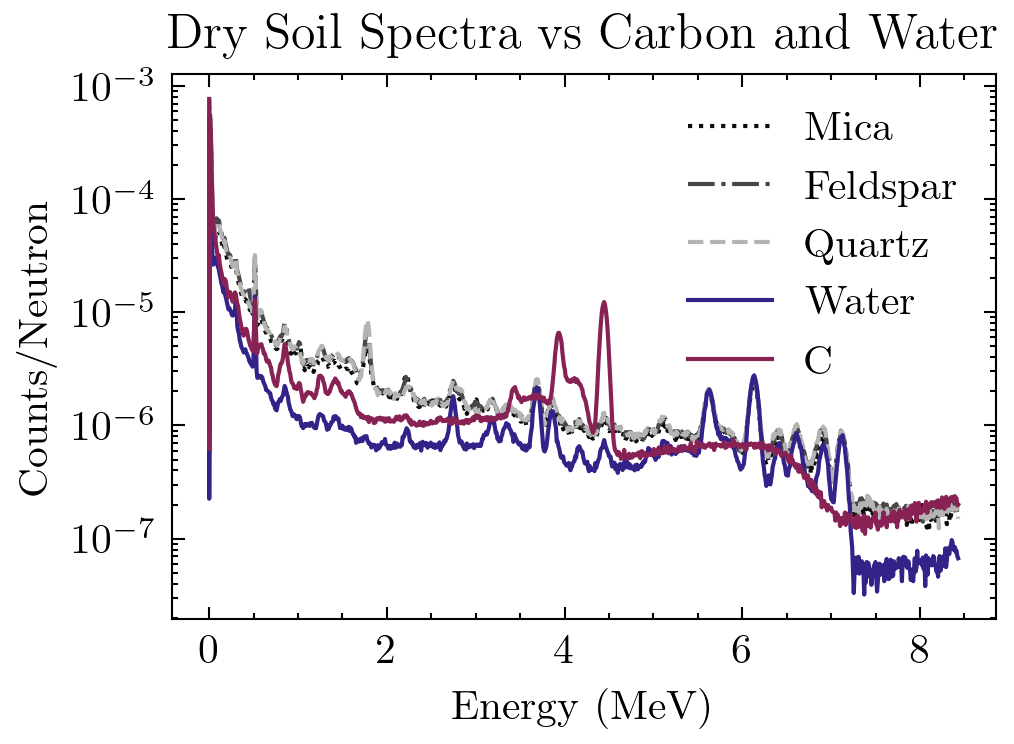

In [73]:


plt.figure()
for label, row in _sims.iterrows():
    c=None
    ls = None
    if pd.isna(row['material']):
        l = row['elem']
    else:
        l = row['material']
    if l in changed_styles:
        c = changed_styles[l]['color']
        ls = changed_styles[l]['linestyle']
    else:
        c = 'black'
        ls = 'dotted'
    plt.plot(_Readings.index, _Readings[label], 
             label=l,
                color=c,
                linestyle=ls
             )
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts/Neutron')
plt.title('Dry Soil Spectra vs Carbon and Water')
plt.legend()
# plt.savefig('../Figures/Simulation/drysoilvscarbonandwater.png', bbox_inches='tight')
plt.show()

In [74]:




# min_bin, max_bin = 4.2, 4.75
# _filt_Readings = _Readings[(DetectorReadings.index >= min_bin) & (DetectorReadings.index <= max_bin)]

# label_1_x = _filt_Readings.index[np.digitize(4.5, _filt_Readings.index)]
# label_1_y_C = _filt_Readings['C'][ _filt_Readings.index[np.digitize(4.5, _filt_Readings.index)]]
# label_1_y_Water = _filt_Readings['Water'][ _filt_Readings.index[np.digitize(4.5, _filt_Readings.index)]]
# label_1_soil = _filt_Readings[_filt_Readings.columns[2]][ _filt_Readings.index[np.digitize(4.6, _filt_Readings.index)]]

# fig, axs = plt.subplot_mosaic([
#     ['A']
#     ],
#     figsize=(double_col_width, double_col_width*.5),
#     )

# ax = axs['A']
# for i, (label, row) in enumerate(_sims.iterrows()):
#     c=None
#     ls = None
#     if pd.isna(row['material']):
#         l = row['elem']
#     else:
#         l = row['material']
#     if l in changed_styles:
#         c = changed_styles[l]['color']
#         ls = changed_styles[l]['linestyle']
#         marker = changed_styles[l].get('marker', None)
#         size = changed_styles[l].get('size', None)
#     else:
#         c = 'black'
#         ls = 'dotted'
#     ax.plot(
#         _Readings.index,
#         _Readings[label] * 100,  # convert to percent
#         label=l,
#         color=c,
#         linestyle=ls,
#         marker=marker,
#         markersize=size
#     )
# ax.set_yscale('log')
# ax.set_xlabel('Energy (MeV)')
# ax.set_ylabel('Counts')
# ax.legend()

# ax0 = fig.add_axes([0.37, 0.60, 0.3*1, 0.25*1])  # [left, bottom, width, height]
# for i, (label, row) in enumerate(_sims.iterrows()):
#     c=None
#     ls = None
#     if pd.isna(row['material']):
#         l = row['elem']
#     else:
#         l = row['material']
#     if l in changed_styles:
#         c = changed_styles[l]['color']
#         ls = changed_styles[l]['linestyle']
#         marker = changed_styles[l].get('marker', None)
#         size = changed_styles[l].get('size', None)
#     else:
#         c = 'black'
#         ls = 'dotted'
#     ax0.plot(
#         _filt_Readings.index,
#         _filt_Readings[label] * 100,  # convert to percent
#         # label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=c,
#         linestyle=ls,
#         marker=marker,
#         markersize=size
#     )
# ax0.set_yscale('log')


# ax0.text(
#     label_1_x + 0.02, 
#     label_1_y_C * 100, 
#     'Carbon', 
#     color=changed_styles['C']['color'],
#     fontsize=8,
#     verticalalignment='bottom'
# )
# ax0.text(
#     label_1_x - 0.10, 
#     label_1_y_Water * 65, 
#     'Water', 
#     color=changed_styles['Water']['color'],
#     fontsize=8,
#     verticalalignment='bottom'
# )

# # ax0.set_xlabel('Energy (MeV)')
# # ax0.tick_params(
# #     axis='y', 
# #     which='both', 
# #     labelsize=8, rotation=70)
# # draw a box on the main plot to show where the inset is
# axins = ax0.get_position()  # get the position of the main axes
# x1, x2 = min_bin, max_bin
# y1, y2 = ax0.get_ylim()
# # draw the rectangle
# for spine in ax0.spines.values():
#     spine.set_edgecolor('black')
# ax.plot([x1, x1, x2, x2, x1], [y1, y2, y2, y1, y1], color='black', linestyle='solid', linewidth=1)
# ax.set_title('Carbon has a distinct peak at 4.44 MeV')

# # add text 
# # plt.tight_layout()
# plt.savefig('../Figures/Simulation/drysoilvscarbonandwater.png', bbox_inches='tight')

# plt.show()


In [75]:
_sims = _sims.iloc[::-1]
_Readings = _Readings[_sims.index]

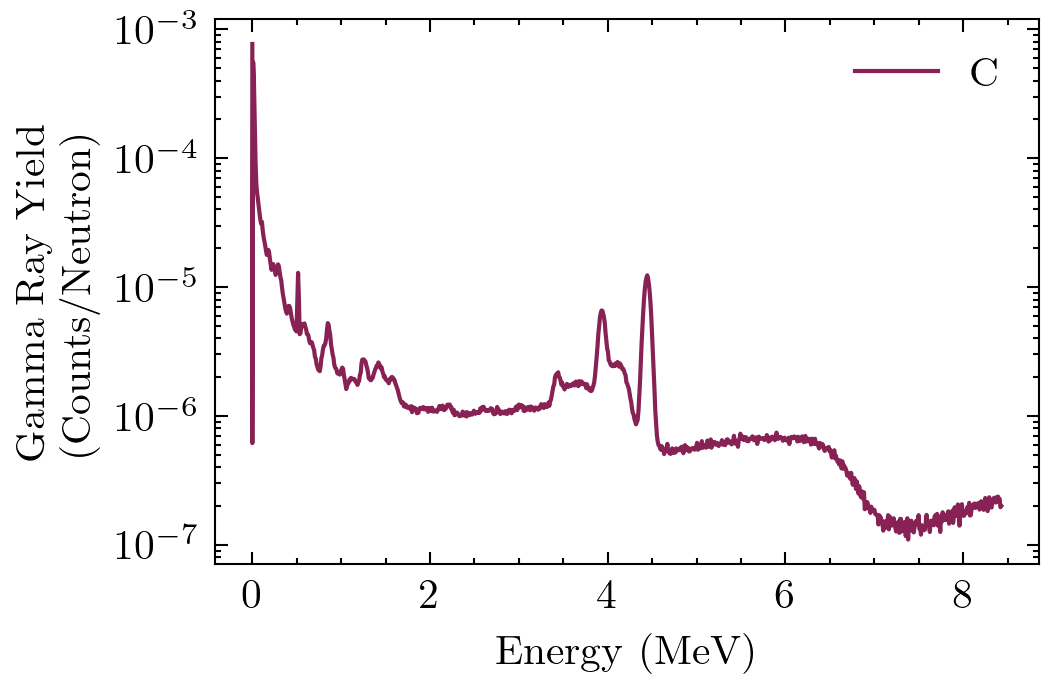

In [76]:


plt.figure()
for label, row in _sims.iterrows():
    c=None
    ls = None
    if pd.isna(row['material']):
        l = row['elem']
    else:
        l = row['material']
    if l in changed_styles:
        c = changed_styles[l]['color']
        ls = changed_styles[l]['linestyle']
    plt.plot(_Readings.index, _Readings[label], 
             label=l,
                color=c,
                linestyle=ls
             )
    break
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Gamma Ray Yield\n(Counts/Neutron)')
# plt.title('Simulated Carbon Spectrum Detection')
plt.legend()
plt.savefig('../Figures/Simulation/carbonspectrum.png', bbox_inches='tight', dpi=300)
plt.show()


In [77]:
feldspar_sims = sims[sims['material'] == 'Feldspar']
feldspar_sims = feldspar_sims[(feldspar_sims['avg_density'] < 1.4) & (feldspar_sims['avg_density'] > 1.3)]

In [78]:
feldspar_sims[['carbon_level', 'hydration_level']]
# 1- (carbon + hydration) is the rest of the material
ternary_data = feldspar_sims[['carbon_level', 'hydration_level']]
ternary_data['rest'] = 1 - (ternary_data['carbon_level'] + ternary_data['hydration_level'])
# ternary_data = ternary_data.set_index(['carbon_level', 'hydration_level', 'rest'])

/tmp/ipykernel_1109661/41217390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ternary_data['rest'] = 1 - (ternary_data['carbon_level'] + ternary_data['hydration_level'])


In [79]:
_sims = feldspar_sims

In [80]:
dry_carbonless_label = _sims[_sims['carbon_level']==0].index[0]

In [81]:
_sims = _sims[_sims['hydration_level']==0]

In [82]:

_Readings = DetectorReadings[_sims.index]
_Readings = _Readings.loc[(_Readings.index < 4.7) & (_Readings.index > 4.2)]

In [83]:
_sims['carbon_level'].to_numpy()

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15])

In [84]:
import matplotlib.cm as cm

# Normalize carbon_level values between 0 and 1 for colormap
carbon_levels = _sims['carbon_level'].to_numpy()
norm = (carbon_levels - carbon_levels.min()) / (carbon_levels.max() - carbon_levels.min())
colors = cm.plasma(norm)

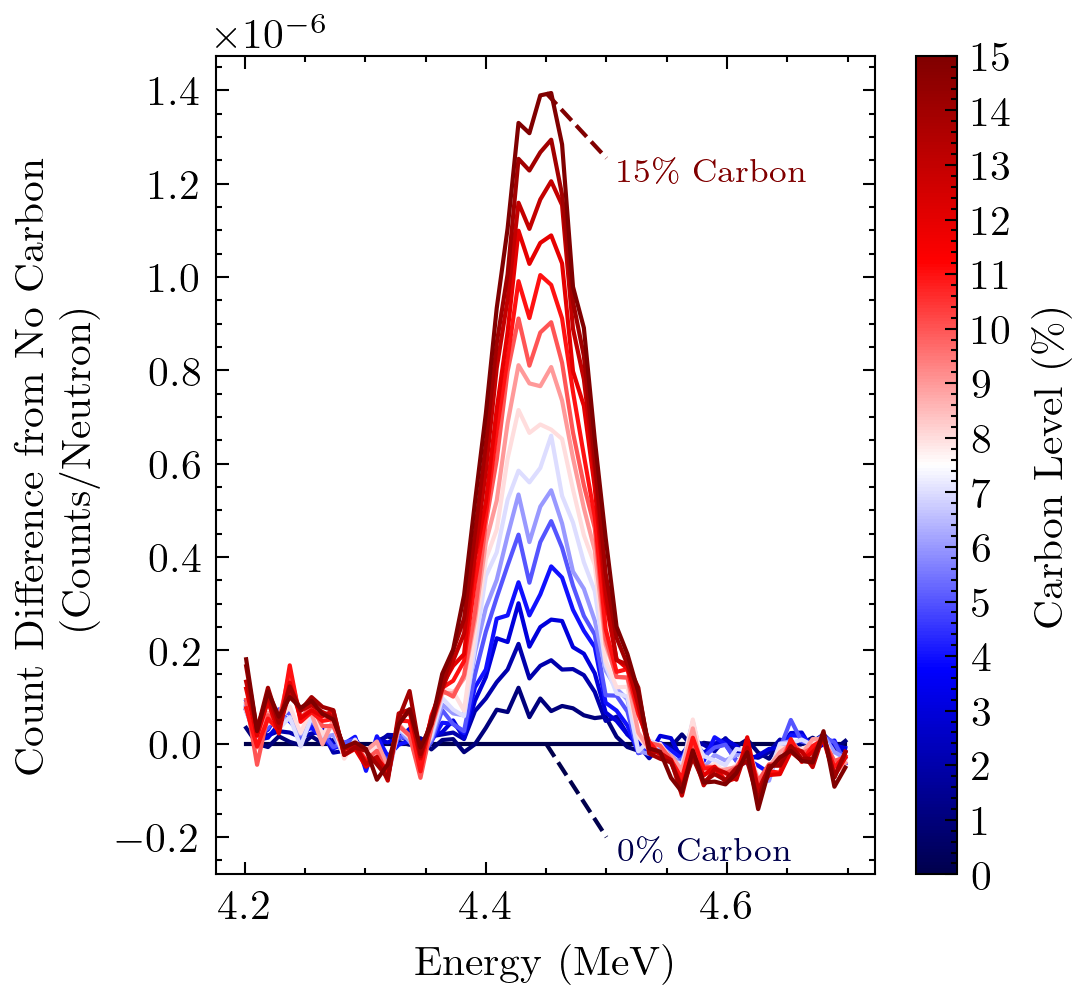

In [85]:
# Normalize carbon_level values between 0 and 1 for colormap
carbon_levels = _sims['carbon_level'].to_numpy()
norm = (carbon_levels - carbon_levels.min()) / (carbon_levels.max() - carbon_levels.min())
colors = cm.seismic(norm)

fig, ax = plt.subplots(figsize=(single_col_width, single_col_width))
diff = (_Readings.values.T - _Readings[dry_carbonless_label].values).T

n_levels = len(carbon_levels)

for i, col in enumerate(_Readings.columns):
	if i == 0:
		linestyle = 'solid'
		label=None
	if i == n_levels - 1:
		linestyle = 'solid'
		label=None
	else:
		linestyle = 'solid'
		label=None
	ax.plot(_Readings.index, diff[:, i], color=colors[i], label=label, linestyle=linestyle, linewidth=1)

ax.text(4.51, diff[:, -1].max()*.9, '15\% Carbon', color=colors[-1], fontsize=8, verticalalignment='top')
plt.plot([4.45,4.5], [diff[:, -1].max(), diff[:, -1].max()*.9], color=colors[-1], linestyle='dashed', linewidth=1)

ax.text(4.51, -2e-7, '0\% Carbon', color=colors[0], fontsize=8, verticalalignment='top')
plt.plot([4.45,4.5], [0, -2e-7], color=colors[0], linestyle='dashed', linewidth=1)

sm = plt.cm.ScalarMappable(cmap=cm.seismic, norm=plt.Normalize(vmin=carbon_levels.min(), vmax=carbon_levels.max()))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Carbon Level (\%)')
cbar.set_ticks(carbon_levels)
cbar.set_ticklabels([f"{level*100:.0f}" for level in carbon_levels])
# ax.set_title('Effect of Carbon on Feldspar Spectrum (Dry)')
ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Count Difference from No Carbon\n(Counts/Neutron)')



plt.savefig('../Figures/Simulation/carboneffect.png', bbox_inches='tight', dpi=300)
plt.show()

In [86]:
carbon_styles = {
    'Low Carbon': {
        'marker': '.',
        'color': 'red'
    },
    'High Carbon': {
        'marker': 'o',
        'color': 'blue'
    }
}

/home/jac2462@uta.edu/Documents/.venv/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


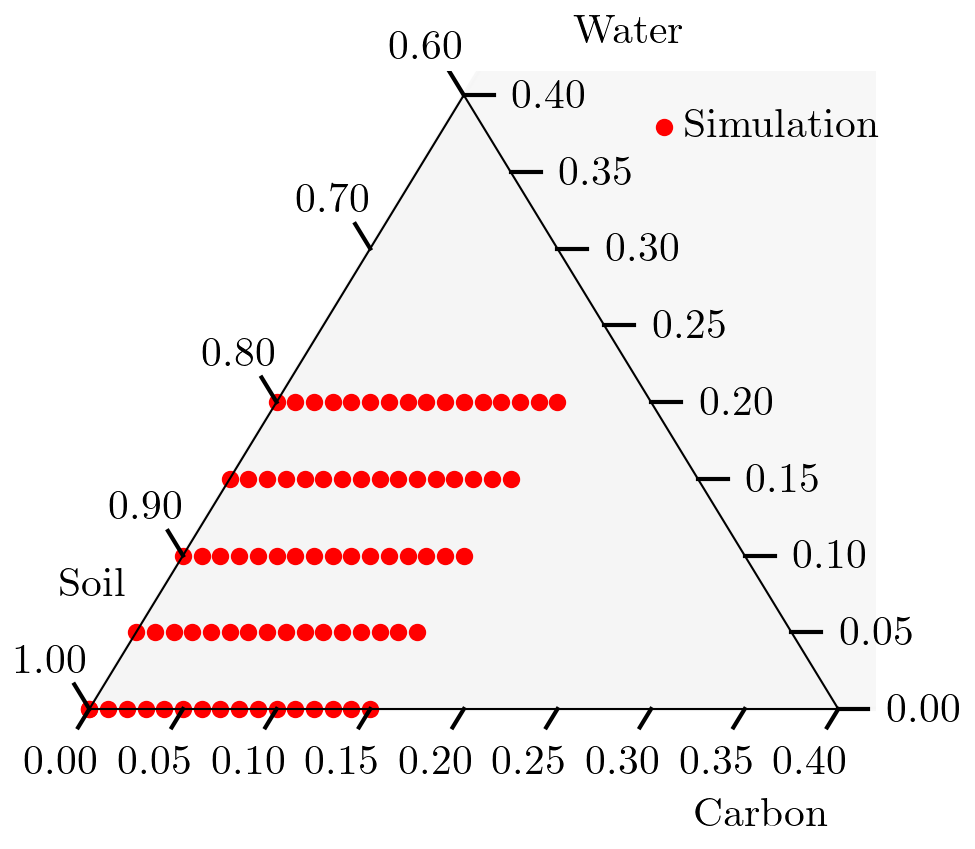

In [87]:
fig, ax = plt.subplots(figsize=(single_col_width, single_col_width * np.sqrt(3)/2))
ta2 = ternary.TernaryAxesSubplot(ax=ax, scale=1)
tax = ternary.TernaryAxesSubplot(ax=ax, scale=0.4)

plt.axis('off')
tax.boundary(linewidth=0.5)
# tax.gridlines(multiple=0.1)
# fig.suptitle("Carbon and Hydration Levels", fontsize=12, y=1)
# tax.set_title("Soil with varying\nCarbon and Hydration Levels")
points = ternary_data[['carbon_level', 'hydration_level', 'rest']].to_numpy()

carbon_level_mask = points[:, 0] <= 0.16
carbon_levels = np.where(carbon_level_mask, 'Low Carbon', 'High Carbon')

for _, point in enumerate(points):
    carbon_level = carbon_levels[_]
    marker = carbon_styles[carbon_level]['marker']
    color = carbon_styles[carbon_level]['color']

    tax.scatter([point], 
                marker=marker, 
                color=color, 
                s=40)
tax.legend(handles=[
    plt.scatter([0], [0], marker=marker, color='red', label='Simulation', s=40)
], 
loc='upper right', 
# fontsize=10, 
bbox_to_anchor=(1.05, 1),
handletextpad=-0.5
)
tax.left_corner_label("Soil", fontsize=10, offset=0.4, position=(-.1, 0.3, 0))
tax.right_corner_label("Carbon", fontsize=10, offset=-0.1, position=(.9, -.075, 0))
tax.top_corner_label("Water", fontsize=10, offset=0.26, position=(0.1, 1.2, 0))
# tax.bottom_corner_label("Carbon Level", fontsize=10, offset=0.16)
# tax.left_corner_label
# tax.ticks(
#     axis='lbr', 
#     linewidth=1, 
#     multiple=.1, 
#     fontsize=8, 
#     offset=0.03,
#     tick_formats="%.1f"
#     # tick_formats="%10.f"
#     )
tax.ticks(
    axis='r',
    linewidth=1,
    multiple=.05,  # or 0.1 for less crowded ticks
    # fontsize=8,
    offset=0.04,
    tick_formats="%.2f",
    # clockwise=True  # two decimals for small scale
)

tax.ticks(
    axis='b',
    linewidth=1,
    multiple=0.05,  # or 0.1 for less crowded ticks
    # fontsize=8,
    offset=0.03,
    tick_formats="%.2f"  # two decimals for small scale
    
)
# tax.ticks(

#     locations=[0.05, 0.10, 0.15, 5],
#     tick_formats="%.2f",
#     linewidth=1, 
#     offset=0.03,
#     multiple=0.05,
# )
# tax.ticks(
#     axis='l',
#     linewidth=1,
#     multiple=0.05,  # or 0.1 for less crowded ticks
#     locations=[0.05, 0.10, 0.15],
#     # fontsize=8,
#     offset=0.03,
#     tick_formats="%.2f",

# )
tax.ticks(
    ticks = [.6, .7, .8, .9, 1],
    locations= [0, .1, .2, .3, .4],
    axis='l',
    linewidth=1,
    multiple=.1,  # or 0.1 for less crowded ticks
    # fontsize=8,
    offset=0.04,
    tick_formats="%.2f",  # two decimals for small scale
    # clockwise=True

)

plt.savefig('../Figures/Simulation/soilternary.png', bbox_inches='tight', dpi=300)
tax.show()

In [88]:
# Edge cases:
# Soil==1 Carbon==0 Hydration==0
# Soil==0.8 Carbon==0.15 Hydration==0
# Soil==0.8 Carbon==0 Hydration==0.2
# Soil==0.8 Carbon==0.15 Hydration==0.2
edge_feldspar_sims = feldspar_sims[
    ((feldspar_sims['carbon_level'] == 0) & (feldspar_sims['hydration_level'] == 0)) | # Soild tab:green
    ((feldspar_sims['carbon_level'] == 0.15) & (feldspar_sims['hydration_level'] == 0)) | # dotted tab:red
    ((feldspar_sims['carbon_level'] == 0) & (feldspar_sims['hydration_level'] == 0.2)) | # dashed tab:blue
    ((feldspar_sims['carbon_level'] == 0.15) & (feldspar_sims['hydration_level'] == 0.2)) # dash-dot tab:purple
]

In [89]:
def style_func(row):
    if (row['carbon_level'] == 0) and (row['hydration_level'] == 0):
        return {
            'label': 'Soil',
            'color': 'green',
            'linestyle': 'solid'
        }
    elif (row['carbon_level'] == 0.15) and (row['hydration_level'] == 0):
        return {
            'label': 'Soil + Carbon',
            'color': 'green',
            'linestyle': ':'
        }
    elif (row['carbon_level'] == 0) and (row['hydration_level'] == 0.2):
        return {
            'label': 'Soil + Hydration',
            'color': 'blue',
            'linestyle': 'solid'
        }
    elif (row['carbon_level'] == 0.15) and (row['hydration_level'] == 0.2):
        return {
            'label': 'Soil + Carbon + Hydration',
            'color': 'blue',
            'linestyle': ':'
        }
    else:
        return {
            'label': '',
            'color': 'black',
            'linestyle': '-'
        }

In [90]:
DetMat = DetectorReadings[edge_feldspar_sims.index].values.T

In [91]:
# plt.figure()
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     # print(label)
#     style = style_func(row)
#     plt.plot(
#         DetectorReadings.index,
#         DetectorReadings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# plt.yscale('log')
# plt.legend()
# plt.xlabel('Energy (MeV)')
# plt.ylabel('Counts/Neutron')
# plt.title('Detector Readings for Natural Soil Edge Cases')
# # make 
# # plt.savefig('../Figures/Simulation/feldsparcarbonandhydration.png', bbox_inches='tight')
# plt.show()

In [92]:
# _Readings = DetectorReadings[edge_feldspar_sims.index]

# min_bin, max_bin = 4.2, 4.75
# _filt_Readings = _Readings[(DetectorReadings.index >= min_bin) & (DetectorReadings.index <= max_bin)]

# fig, axs = plt.subplot_mosaic([
#     ['A']
#     ],
#     figsize=(double_col_width, double_col_width*np.sqrt(2)/2),
#     )

# ax = axs['A']
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax.plot(
#         _Readings.index,
#         _Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax.set_yscale('log')
# ax.set_xlabel('Energy (MeV)')
# ax.set_ylabel('Counts/Neutron')
# ax.legend()
# # make frame red

# ax0 = fig.add_axes([0.35, 0.50, 0.3*1, 0.35*1])  # [left, bottom, width, height]
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax0.plot(
#         _filt_Readings.index,
#         _filt_Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax0.set_yscale('log')
# # ax0.set_xlabel('Energy (MeV)')
# # ax0.tick_params(
# #     axis='y', 
# #     which='both', 
# #     labelsize=8, rotation=70)
# # draw a box on the main plot to show where the inset is
# axins = ax0.get_position()  # get the position of the main axes
# x1, x2 = min_bin, max_bin
# y1, y2 = ax0.get_ylim()
# # draw the rectangle
# for spine in ax0.spines.values():
#     spine.set_edgecolor('black')
# ax.plot([x1, x1, x2, x2, x1], [y1, y2, y2, y1, y1], color='black', linestyle='solid', linewidth=1)
# ax.set_title('Detector Readings for Natural Soil Edge Cases (Feldspar)')
# # plt.tight_layout()
# # plt.savefig('../Figures/Simulation/carboneffect.png', bbox_inches='tight')

# plt.show()


In [93]:

# _Readings = DetectorReadings[edge_feldspar_sims.index]

# min_bin, max_bin = 4.2, 4.75
# _filt_Readings = _Readings[(DetectorReadings.index >= min_bin) & (DetectorReadings.index <= max_bin)]

# fig, axs = plt.subplot_mosaic([
#     ['A']
#     ],
#     figsize=(double_col_width, double_col_width*np.sqrt(2)/2),
#     )

# ax = axs['A']
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax.plot(
#         _Readings.index,
#         _Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax.set_yscale('log')
# ax.set_xlabel('Energy (MeV)')
# ax.set_ylabel('Counts/Neutron')
# ax.legend()
# # make frame red

# ax0 = fig.add_axes([0.35, 0.50, 0.3*1, 0.35*1])  # [left, bottom, width, height]
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax0.plot(
#         _filt_Readings.index,
#         _filt_Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax0.set_yscale('log')
# # ax0.set_xlabel('Energy (MeV)')
# # ax0.tick_params(
# #     axis='y', 
# #     which='both', 
# #     labelsize=8, rotation=70)
# # draw a box on the main plot to show where the inset is
# axins = ax0.get_position()  # get the position of the main axes
# x1, x2 = min_bin, max_bin
# y1, y2 = ax0.get_ylim()
# # draw the rectangle
# for spine in ax0.spines.values():
#     spine.set_edgecolor('black')
# ax.plot([x1, x1, x2, x2, x1], [y1, y2, y2, y1, y1], color='black', linestyle='solid', linewidth=1)
# ax.set_title('Detector Readings for Natural Soil Edge Cases (Feldspar)')
# # plt.tight_layout()
# # plt.savefig('../Figures/Simulation/carboneffect.png', bbox_inches='tight')

# plt.show()


In [94]:
# _Readings = DetectorReadings[edge_feldspar_sims.index]

# min_bin, max_bin = 5.9, 6.3
# _filt_Readings = _Readings[(DetectorReadings.index >= min_bin) & (DetectorReadings.index <= max_bin)]

# fig, axs = plt.subplot_mosaic([
#     ['A']
#     ],
#     figsize=(double_col_width, double_col_width*np.sqrt(2)/2),
#     )

# ax = axs['A']
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax.plot(
#         _Readings.index,
#         _Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax.set_yscale('log')
# ax.set_xlabel('Energy (MeV)')
# ax.set_ylabel('Counts/Neutron')
# ax.legend()
# # make frame red

# ax0 = fig.add_axes([0.35, 0.50, 0.3*1, 0.35*1])  # [left, bottom, width, height]
# for i, (label, row) in enumerate(edge_feldspar_sims.iterrows()):
#     style = style_func(row)
#     ax0.plot(
#         _filt_Readings.index,
#         _filt_Readings[label] * 100,  # convert to percent
#         label=f"C: {row['carbon_level']*100:.0f}\%, H2O: {row['hydration_level']*100:.0f}\%",
#         color=style['color'],
#         linestyle=style['linestyle']
#     )
# ax0.set_yscale('log')
# # ax0.set_xlabel('Energy (MeV)')
# # ax0.tick_params(
# #     axis='y', 
# #     which='both', 
# #     labelsize=8, rotation=70)
# # draw a box on the main plot to show where the inset is
# axins = ax0.get_position()  # get the position of the main axes
# x1, x2 = min_bin, max_bin
# y1, y2 = ax0.get_ylim()
# # draw the rectangle
# for spine in ax0.spines.values():
#     spine.set_edgecolor('black')
# ax.plot([x1, x1, x2, x2, x1], [y1, y2, y2, y1, y1], color='black', linestyle='solid', linewidth=1)
# ax.set_title('Detector Readings for Natural Soil Edge Cases (Feldspar)')
# # plt.tight_layout()
# # plt.savefig('../Figures/Simulation/carboneffect.png', bbox_inches='tight')

# plt.show()


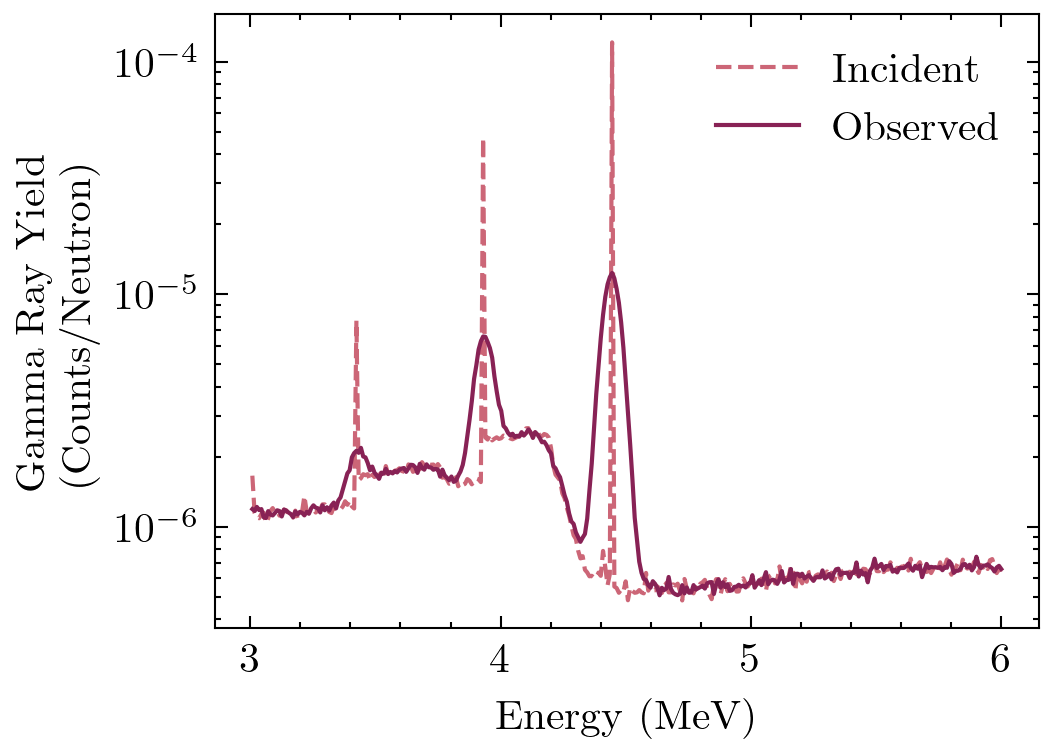

In [96]:

IncidentSpectrums = pd.read_csv('IncidentSpectrums.csv', index_col=0)

_bins = IncidentSpectrums.index
_bins = _bins[(_bins<6) & (_bins>3)]
example_label = 'C'
example_row = sims.loc[example_label]
example_counts = IncidentSpectrums.loc[_bins, example_label]
example_geb = DetectorReadings.loc[_bins, example_label]

plt.figure(figsize=(single_col_width, single_col_width * 0.75))
# plt.plot(DetectorReadings.index, example_counts, color='green', label=f"C: {example_row['carbon_level']*100:.0f}%, H2O: {example_row['hydration_level']*100:.0f}%")
plt.plot(_bins, example_counts, label='Incident', color='#CC6677', linestyle='dashed')
# plt.plot(_bins, A @ example_counts, label='After GEB', color='black')
plt.plot(_bins, example_geb, label='Observed', color='#882255')
plt.yscale('log')
plt.xlabel('Energy (MeV)')
plt.ylabel('Gamma Ray Yield\n(Counts/Neutron)')
# plt.title('Incident vs Detected Spectrum for Carbon')
plt.legend()
# plt.xlim(0, 5)

# plt.ylim(5e-7, 5e-6)

plt.savefig('../Figures/Simulation/GEBvsIncident.png', bbox_inches='tight', dpi=300)
plt.show()